# Linear Regression — Assumptions, Diagnostics & Polynomial Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/01-supervised-learning/01-linear-regression/03-assumptions-and-polynomial-regression/notes.ipynb)

*Part 3 of 3 on Linear Regression, continuing from
[Multivariate Regression & Preprocessing](../02-multivariate-and-preprocessing/notes.ipynb).*

**Last time:** using every feature at once, scaling, one-hot encoding, outliers, Adjusted R², StatsModels.
**Today's central question:** a model with good performance isn't always a good model — we learn to verify one,
and what to do when the data itself isn't a straight line.


## 1. Recap, and loading the data again

Self-contained like the rest of this series — reloading the same standardized Cars24 dataset used throughout.


In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.api as sms
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

DATA_URL = "https://raw.githubusercontent.com/28101991SUNNY/DSML-Classical-Machine-Learning-1/main/cars24-car-price-clean.csv"
DATA_PATH = "data/cars24-car-price-clean.csv"

if not os.path.exists(DATA_PATH):
    os.makedirs("data", exist_ok=True)
    pd.read_csv(DATA_URL).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-1.111046,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,-0.223944,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-0.915058,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.892365,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,-0.182683,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


## 2. The 5 assumptions of Linear Regression

A high R² doesn't automatically mean a *trustworthy* model. Linear Regression's coefficients, p-values, and
confidence intervals are only valid when the data satisfies five assumptions underneath it. Violating them
doesn't always visibly break the model's predictions — but it can silently invalidate everything you'd want to
say *about* those predictions.

| # | Assumption | Severity | What it means |
|---|---|---|---|
| 1 | Linearity | 🔴 Critical | Each feature relates to the target in a straight line |
| 2 | No multicollinearity | 🔴 Critical | Features aren't linearly derivable from each other |
| 3 | Normally distributed errors | 🟠 Important | Residuals follow a bell curve centered at zero |
| 4 | Error independence | 🟠 Important | Residuals show no pattern or correlation with each other |
| 5 | Homoscedasticity | 🟠 Important | Residual spread stays roughly constant across all predictions |

**Assumption 1 in a bit more detail — Linearity.** If the true relationship is a curve (an S-curve, an
exponential, a wave), a straight line structurally cannot capture it, no matter how well you fit `m` and `c`.

- *How to check:* scatter plots of each feature against the target; residual plots — a visible pattern in the
  residuals means linearity is violated.
- *How to fix:* Polynomial Regression (Section 5) — transform the features into higher-order terms so a linear
  model can still fit the (now-linear-in-the-new-features) relationship.
- *Real examples of non-linear relationships:* electricity consumption vs. year (S-curve), sales vs. ad spend
  (diminishing returns), blood pressure vs. BMI.

The rest of this notebook walks through Assumptions 2 through 5 one at a time, with the actual detection code for
each.


## 3. Multicollinearity and the Variance Inflation Factor (VIF)

**Multicollinearity** happens when one feature can be predicted from the others — e.g. if
$x_2 = 3x_3 + 2x_4$, then $x_2$ carries no information the model doesn't already have from $x_3$ and $x_4$. The
model can no longer isolate $x_2$'s *own* effect, so its coefficient becomes unstable and unreliable.

**In our dataset:** `year` and `age` are almost perfectly correlated — `age` is just `current_year − year`.
Including both leaves the model unable to tell which one is actually driving the price.

**Symptoms:** unexpectedly large coefficients (or the wrong sign), high standard errors despite a good overall
R², a large condition number in a StatsModels summary.

### 3.1 How VIF works

For each feature $x_j$: treat it as the *target*, fit a regression predicting it from every other feature, and
look at that regression's $R^2_j$ — a high $R^2_j$ means $x_j$ is well-explained by the rest, i.e. redundant.

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

| VIF | Interpretation | Action |
|---|---|---|
| > 10 | Very high multicollinearity | Remove |
| 5 – 10 | High | Consider removing |
| < 5 | Acceptable | Keep |


In [2]:
X_tr_vif, X_te_vif, y_tr_vif, y_te_vif = train_test_split(
    df[df.columns.drop('selling_price')], df['selling_price'], test_size=0.2, random_state=2
)

vif = pd.DataFrame()
vif['Features'] = X_tr_vif.columns
vif['VIF'] = [variance_inflation_factor(X_tr_vif.values, i) for i in range(X_tr_vif.shape[1])]
vif = vif.sort_values(by="VIF", ascending=False).reset_index(drop=True)
vif

/tmp/ipykernel_2084/730748410.py:7: UserWarning: The design matrix is poorly conditioned (condition number=5.05e+15). VIF calculations may be numerically unstable.
  vif['VIF'] = [variance_inflation_factor(X_tr_vif.values, i) for i in range(X_tr_vif.shape[1])]
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.11/dist-packages/statsmodels/stat

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


,Features,VIF
0,year,1.000800e+15
1,age,1.000800e+15
2,Petrol,1.829670e+01
3,Diesel,1.729778e+01
4,>5,1.304478e+01
5,5,1.175045e+01
6,engine,6.256598e+00
7,model,5.777104e+00
8,max_power,4.996432e+00
9,mileage,3.221178e+00


`year` (and its twin `age`) come back with an enormous VIF — the warnings printed above ("rank-deficient",
"poorly conditioned") *are* the multicollinearity: statsmodels is telling us the exact same thing the VIF numbers
are, from a different angle. That perfect $\text{corr}(\text{year}, \text{age}) = -1$ is the textbook case this
whole diagnostic exists to catch.

### 3.2 Iterative elimination

Remove the worst offender, recompute VIF on what's left, repeat — until every remaining feature is under the
threshold, or removing more would cost too much Adjusted R².


In [3]:
cols = list(X_tr_vif.columns)
feats_removed = []
vif_threshold = 5
adj_r2_threshold = 0.85

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    while True:
        X_current = X_tr_vif[cols]
        vifs = [variance_inflation_factor(X_current.values, i) for i in range(X_current.shape[1])]
        vif_now = pd.DataFrame({'Features': cols, 'VIF': vifs}).sort_values('VIF', ascending=False).reset_index(drop=True)

        X_sm_current = sm.add_constant(X_current)
        current_fit = sm.OLS(y_tr_vif.values, X_sm_current).fit()

        if vif_now.iloc[0]['VIF'] < vif_threshold or current_fit.rsquared_adj < adj_r2_threshold:
            break

        feats_removed.append(vif_now.iloc[0]['Features'])
        cols = [c for c in cols if c != vif_now.iloc[0]['Features']]

print("Features removed:", feats_removed)
print("Final Adjusted R²:", current_fit.rsquared_adj)
vif_now

Features removed: ['year', 'Petrol', '>5', 'engine', 'model']
Final Adjusted R²: 0.8318553555450335


,Features,VIF
0,max_power,2.713200
1,make,2.330356
2,mileage,2.242645
3,Manual,1.659314
4,Diesel,1.528390
5,5,1.451266
6,age,1.313376
7,km_driven,1.196521
8,Electric,1.172746
9,Individual,1.081879


✅ We went from 17 features down to a smaller, decorrelated set with every VIF comfortably under 5, and barely
gave up any Adjusted R² in the process — the redundant features weren't adding real predictive power, just
noise in the coefficients.


## 4. Residual diagnostics — normality, independence, homoscedasticity

The remaining three assumptions are all checked by looking at the model's *residuals* (errors), not its
predictions directly.

### 4.1 Assumption 3 — errors should be normally distributed

Well-specified residuals should look like a bell curve centered at zero. If they don't, it's often a sign of
outliers, a skewed target, or a genuinely misspecified (e.g. non-linear) model.


/tmp/ipykernel_2084/193856747.py:2: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  sm_model_full = sm.OLS(y_tr_vif.values, X_sm_full).fit()


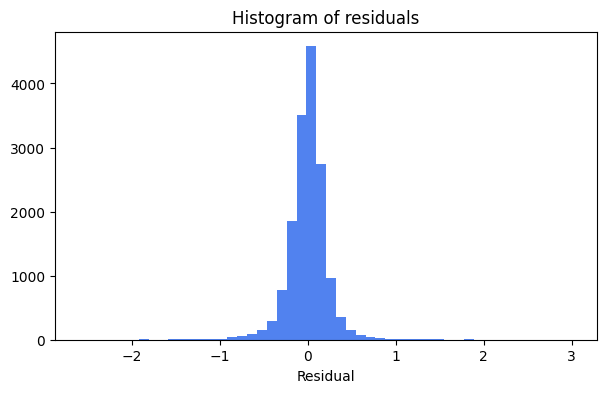

In [4]:
X_sm_full = sm.add_constant(X_tr_vif)
sm_model_full = sm.OLS(y_tr_vif.values, X_sm_full).fit()

y_hat = sm_model_full.predict(X_sm_full)
errors = y_hat - y_tr_vif.values

plt.figure(figsize=(7, 4))
plt.hist(errors, bins=50, color="#2563EB", alpha=0.8)
plt.xlabel("Residual"); plt.title("Histogram of residuals")
plt.show()

In [5]:
shapiro_sample = errors if len(errors) <= 5000 else np.random.default_rng(0).choice(errors, 5000, replace=False)
shapiro_result = stats.shapiro(shapiro_sample)
print("Shapiro-Wilk statistic:", shapiro_result.statistic)

Shapiro-Wilk statistic: 0.8434437665327403


| Statistic | Interpretation |
|---|---|
| close to 1.0 | strong normality |
| 0.85 – 0.95 | moderate normality — acceptable on large datasets |
| below 0.8 | significant departure — investigate outliers |

### 4.2 Assumption 4 — errors should be independent

A scatter of residuals vs. the target should show no visible pattern — just random scatter around zero. This is
mostly a time-series concern (errors at time $t$ correlating with errors at $t-1$, called autocorrelation); for
a cross-sectional dataset like ours it's rarely an issue.

The **Durbin-Watson statistic**, printed in every StatsModels summary, tests exactly this — values near 2.0 mean
no autocorrelation; values near 0 or 4 signal a problem.


In [6]:
print("Durbin-Watson:", sm.stats.stattools.durbin_watson(sm_model_full.resid))

Durbin-Watson: 2.002825256244877


### 4.3 Assumption 5 — homoscedasticity (constant error variance)

The residuals' spread should stay roughly constant across all predicted values. Its opposite,
**heteroscedasticity**, shows up as a cone shape — errors fanning out (or in) as predictions grow.


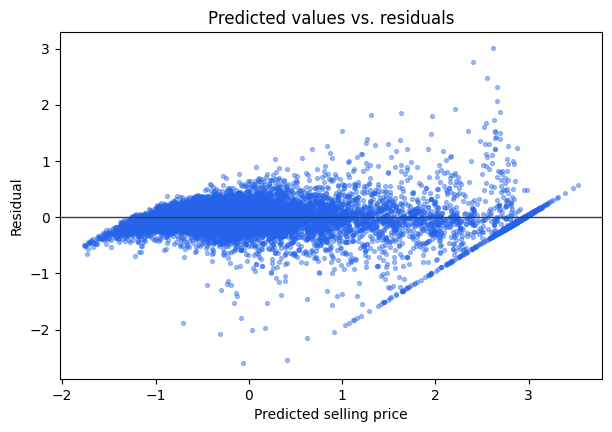

In [7]:
plt.figure(figsize=(7, 4.5))
plt.scatter(y_hat, errors, s=8, alpha=0.4, color="#2563EB")
plt.axhline(0, color="#374151", lw=1)
plt.xlabel("Predicted selling price"); plt.ylabel("Residual")
plt.title("Predicted values vs. residuals")
plt.show()

In [8]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gq_stat, gq_pvalue, _ = sms.het_goldfeldquandt(y_tr_vif, X_sm_full)
print(f"Goldfeld-Quandt F statistic: {gq_stat:.3f}")
print(f"Goldfeld-Quandt p-value:     {gq_pvalue:.3f}")

Goldfeld-Quandt F statistic: 0.991
Goldfeld-Quandt p-value:     0.656


The Goldfeld-Quandt test formally compares residual variance in the lower half of the data vs. the upper half.
An F-statistic near 1 with a p-value above 0.05 means we fail to reject the null of equal variance —
homoscedasticity holds.

> **If you do find heteroscedasticity:** transform the target (`log(y)`, `sqrt(y)`, or Box-Cox), remove outliers
> that are inflating variance in one region, or move to weighted least squares regression.


## 5. Polynomial Regression — when the data isn't a line

When Assumption 1 (linearity) fails — the true relationship visibly curves — the fix isn't a different
algorithm, it's different *features*. Real non-linear examples: electricity/energy consumption vs. year
(S-curve), seasonal sales vs. month (sinusoidal), blood pressure vs. BMI.

**The idea:** instead of feeding the model raw $x$, feed it $x$ raised to increasing powers:

$$
\phi(x) = [1, x, x^2, x^3, \ldots, x^d]
$$

then fit ordinary Linear Regression on these transformed features:

$$
\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \cdots + w_d x^d
$$

> **Key insight:** this is still *linear* regression — linear in the parameters $w$. The curve comes from the
> transformed features, not from a fundamentally different model, which means the exact same OLS / gradient
> descent machinery from the first notebook still applies unchanged.

| Degree | Equation | Shape |
|---|---|---|
| 1 | $w_0 + w_1 x$ | straight line — standard LR |
| 2 | $w_0 + w_1 x + w_2 x^2$ | parabola |
| 3 | $w_0 + w_1 x + w_2 x^2 + w_3 x^3$ | cubic, one inflection point |
| $n$ | … | increasingly flexible — and increasingly prone to overfitting |

### 5.1 Worked example — US primary energy consumption vs. year

Real, public data from Our World in Data: US total primary energy consumption, 1965–2024 — a genuine
non-linear growth curve (rapid growth, then a plateau), the same shape the class's electricity-consumption
example demonstrates.


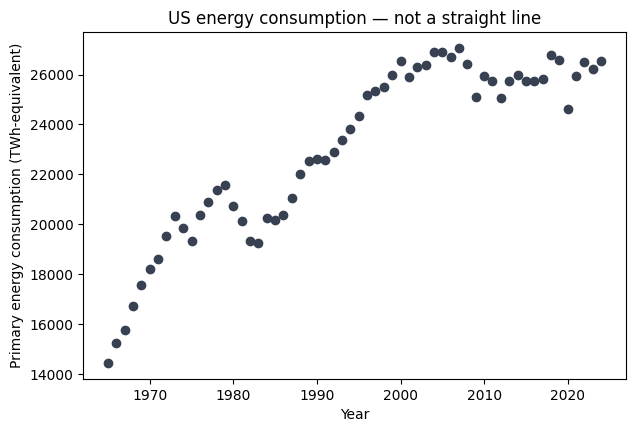

In [9]:
ENERGY_URL = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
ENERGY_PATH = "data/us-energy-consumption.csv"

if not os.path.exists(ENERGY_PATH):
    energy_df = pd.read_csv(ENERGY_URL)
    us_energy = energy_df[energy_df['country'] == 'United States'][['year', 'primary_energy_consumption']].dropna()
    us_energy.to_csv(ENERGY_PATH, index=False)

energy = pd.read_csv(ENERGY_PATH).reset_index(drop=True)
plt.figure(figsize=(7, 4.5))
plt.scatter(energy['year'], energy['primary_energy_consumption'], color="#374151")
plt.xlabel("Year"); plt.ylabel("Primary energy consumption (TWh-equivalent)")
plt.title("US energy consumption — not a straight line")
plt.show()

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn import metrics

# every 5th point held out as the test set, matching the class's split strategy
size = len(energy.index)
test_idx = range(0, size, 5)
train = energy[~energy.index.isin(test_idx)]
test = energy[energy.index.isin(test_idx)]

X_train_e = train['year'].values.reshape(-1, 1)
y_train_e = train['primary_energy_consumption']
X_test_e = test['year'].values.reshape(-1, 1)
y_test_e = test['primary_energy_consumption']

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

Train: 48 rows | Test: 12 rows


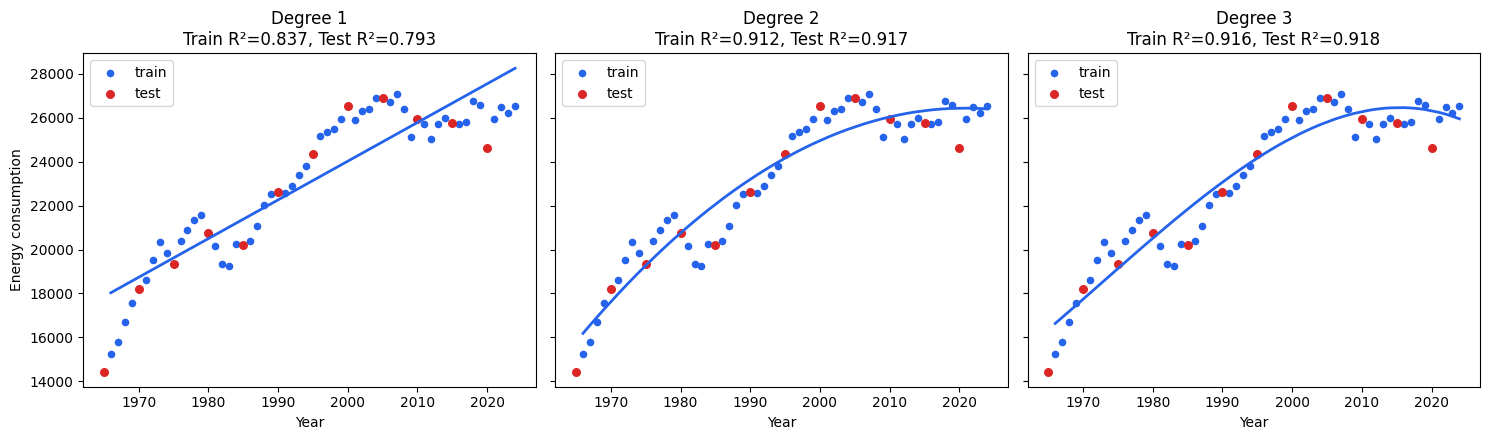

Degree 1: Train R² = 0.837, Test R² = 0.793
Degree 2: Train R² = 0.912, Test R² = 0.917
Degree 3: Train R² = 0.916, Test R² = 0.918


In [11]:
degrees = [1, 2, 3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
r2_train, r2_test = [], []

for ax, degree in zip(axes, degrees):
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('model', LinearRegression())
    ])
    pipeline.fit(X_train_e, y_train_e)

    tr = metrics.r2_score(y_train_e, pipeline.predict(X_train_e))
    te = metrics.r2_score(y_test_e, pipeline.predict(X_test_e))
    r2_train.append(tr); r2_test.append(te)

    order = np.argsort(X_train_e.flatten())
    ax.scatter(X_train_e, y_train_e, color="#2563EB", s=20, label="train")
    ax.plot(X_train_e[order], pipeline.predict(X_train_e)[order], color="#2563EB", lw=2)
    ax.scatter(X_test_e, y_test_e, color="#DC2626", s=30, label="test")
    ax.set_title(f"Degree {degree}\nTrain R²={tr:.3f}, Test R²={te:.3f}")
    ax.set_xlabel("Year")
    ax.legend()

axes[0].set_ylabel("Energy consumption")
plt.tight_layout()
plt.show()

for d, tr, te in zip(degrees, r2_train, r2_test):
    print(f"Degree {d}: Train R² = {tr:.3f}, Test R² = {te:.3f}")

Degree 1 clearly misses the curvature — both R² scores land noticeably lower than degree 2. Degree 2 captures
the bend well. Degree 3 barely improves on degree 2 at all — extra complexity with nothing to show for it.

> **Lesson:** always evaluate on held-out test data to pick the degree. Here, degree 2 is the sweet spot;
> pushing further would start trading real fit for overfitting, which is exactly what the next section names.


## 6. The Bias-Variance Tradeoff

One of the most fundamental ideas in all of machine learning — every model balances two competing failure modes.

**The student analogy:**

| | 😴 The under-studier (underfitting) | 🎓 The over-studier (overfitting) |
|---|---|---|
| What they did | Skimmed chapter headings | Memorized every practice question |
| Practice problems | Can't answer them | Perfect score |
| The real exam (new questions) | Fails | Fails — new phrasing throws them off |
| Train score | Low | High |
| Test score | Low | Low |

| Scenario | Train R² | Test R² | Problem |
|---|---|---|---|
| Underfitting | Low | Low | Model too simple — misses the real pattern |
| Overfitting | High | Low | Model too complex — memorized training noise |
| Just right | Good | Good | Generalizes to new data |

**In bias/variance terms:**

- **High bias, low variance** — consistently misses in the same wrong direction. Underfitting.
- **Low bias, high variance** — aims correctly on average but scatters wildly run to run. Overfitting.
- **Low bias, low variance** — the goal.
- **High bias, high variance** — the worst case, both problems compounding.


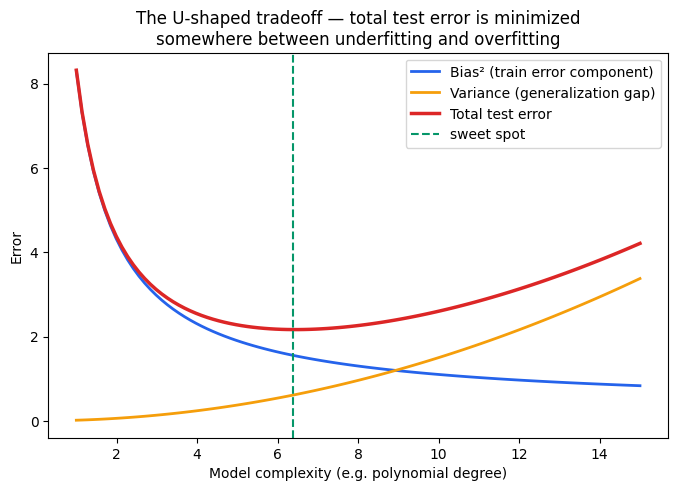

In [12]:
complexity = np.linspace(1, 15, 100)
bias_sq = 8 / complexity + 0.3
variance = 0.015 * complexity**2
total_error = bias_sq + variance

best_idx = np.argmin(total_error)

plt.figure(figsize=(8, 5))
plt.plot(complexity, bias_sq, color="#2563EB", lw=2, label="Bias² (train error component)")
plt.plot(complexity, variance, color="#F59E0B", lw=2, label="Variance (generalization gap)")
plt.plot(complexity, total_error, color="#DC2626", lw=2.5, label="Total test error")
plt.axvline(complexity[best_idx], color="#059669", ls="--", lw=1.5, label="sweet spot")
plt.xlabel("Model complexity (e.g. polynomial degree)")
plt.ylabel("Error")
plt.title("The U-shaped tradeoff — total test error is minimized\nsomewhere between underfitting and overfitting")
plt.legend()
plt.show()

**Connecting this to polynomial degree specifically** — a model $\hat{y} = w_0 + w_1x + w_2x^2 + w_3x^3 + w_4x^4$:

| Model | Non-zero weights | Complexity | Risk |
|---|---|---|---|
| Highest-degree | all of $w_1 \ldots w_4$ | highest | overfitting |
| Balanced | $w_1, w_2$ only | medium | — |
| Degree 1 | $w_1$ only | lowest | underfitting |

The more non-zero higher-order weights a model is allowed, the more it can contort itself to fit the training
data exactly — which is precisely what drives variance up and risks memorizing noise instead of the real trend.
This is exactly the degree-1-vs-2-vs-3 comparison from Section 5, generalized to any model.

> **The goal:** find the complexity where both train and test error are acceptably low — the generalization
> sweet spot where the model has learned the real pattern, not the noise.


## 7. Summary — revision cheat sheet

This closes out the 3-part Linear Regression series. Full recap:

**The model:** $y = m_1x_1 + m_2x_2 + \cdots + c$ — a straight line (one feature) or a hyperplane (two or more
features) fit through the data. Every ML algorithm reduces to the same three ingredients: **Model** (predicts),
**Cost Function** (scores the error), **Optimizer** (reduces it).

**Fitting it — the loop:** start with random $m$, $c$ → predict → measure error with MSE → nudge $m$, $c$ downhill
via gradient descent → repeat until the error stops meaningfully improving.

**Core definitions:**
- *MSE (the cost function)* — $\frac{1}{n}\sum(y - y_{predicted})^2$; convex, so it has a single global minimum
  and gradient descent always finds it.
- *Gradient descent (the optimizer)* — repeatedly step each parameter opposite its gradient:
  $x = x - \text{learning_rate} \cdot \frac{d(Error)}{dx}$.
- *R² (coefficient of determination)* — $1 - RSS/TSS$; how much better your model does than just predicting the
  mean every time. Range $(-\infty, 1]$; near 1 is a great fit, near 0 is no better than the mean, negative is
  worse than the mean.
- *Adjusted R²* — $R^2$ penalized for feature count; the fair way to compare models with different numbers of
  features, since plain $R^2$ never decreases from adding *any* feature, useful or not.
- *Feature scaling* — Z-score standardization $(x-\mu)/\sigma$ or Min-Max $(x-\min)/(\max-\min)$; makes
  coefficients comparable and helps gradient descent converge. Min-Max is outlier-sensitive; standardization is
  the safer default.

**Preprocessing checklist, built up across this series:**
- Split into train/test *before* fitting, and never let the model see test data during training.
- One-hot encode categorical features (dropping one column to avoid redundancy).
- Impute missing values with the median (robust to skew/outliers) rather than the mean.
- Detect and treat outliers — squared error means a single extreme point can drag the whole line off course.

**Trusting the model — the 5 assumptions:**
1. Linearity — fix with Polynomial Regression if violated.
2. No multicollinearity — detect with VIF ($1/(1-R_j^2)$), fix by removing high-VIF features.
3. Normal residuals — check with a histogram + Shapiro-Wilk.
4. Independent errors — check with Durbin-Watson (≈2.0 is healthy).
5. Homoscedasticity — check visually (residuals vs. predicted) and with the Goldfeld-Quandt test.

**Generalization — the Bias-Variance Tradeoff:** too simple underfits (high bias, low variance, poor on both
train and test); too complex overfits (low bias, high variance, great on train, poor on test). The right model
complexity minimizes total test error, not train error.

**Next up:** Regularization (Ridge / Lasso — penalizing large weights directly, rather than manually removing
features) and Cross-Validation (a more robust way to pick that model complexity than a single train/test split).
